In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import joblib

In [2]:
df = pd.read_csv(
    r"C:\Users\sujee\Desktop\Heart_disease prediction1\Heart_Disease_Prediction.csv"
)

# Model Evaluation

The trained models are evaluated using multiple classification metrics.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Evaluation Function

In [5]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{name}")
    print("-" * 40)

    print(
        "Accuracy :",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall   :",
        recall_score(y_true, y_pred)
    )

    print(
        "F1 Score :",
        f1_score(y_true, y_pred)
    )

    print(
        "ROC-AUC  :",
        roc_auc_score(y_true, y_prob)
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

# 11. Final Evaluation Model

The final Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [13]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [14]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (216, 13)
X_test : (54, 13)
y_train: (216,)
y_test : (54,)


In [17]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8518518518518519
Precision: 0.7857142857142857
Recall   : 0.9166666666666666
F1 Score : 0.8461538461538461
ROC-AUC  : 0.898611111111111


# 12. Confusion Matrix

A confusion matrix is used to visualize the correct and incorrect predictions made by the classification model.

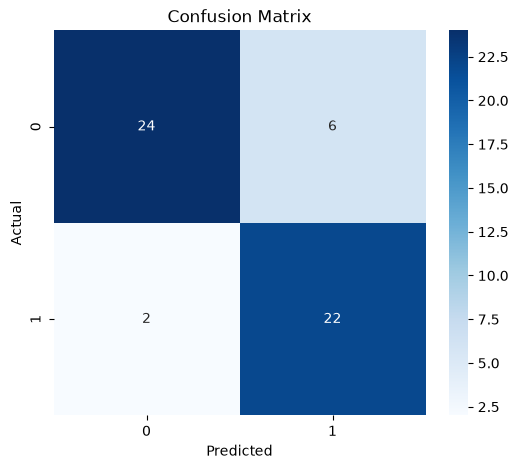

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 13. ROC Curve

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds.

The Area Under the Curve (AUC) is used to measure the model's ability to distinguish between the two classes.

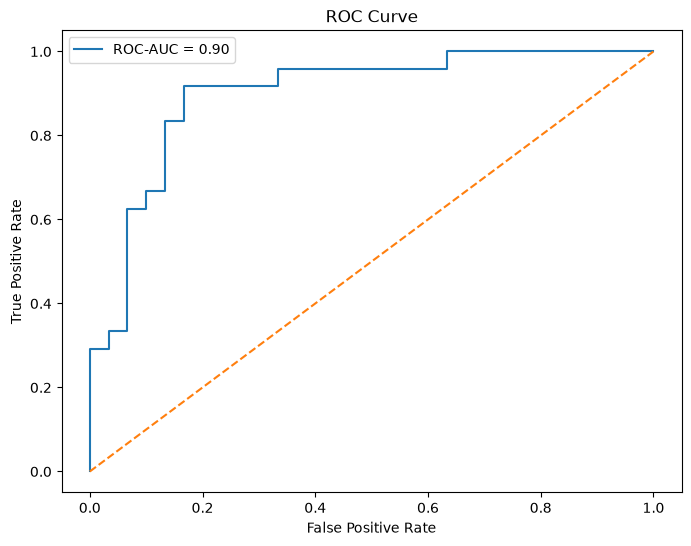

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()